<a href="https://colab.research.google.com/github/Ismailchan/Demand-Forecasting-and-Inventory-optimization/blob/main/Demand_and_inventory.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [2]:
url = 'https://raw.githubusercontent.com/Ismailchan/Demand-Forecasting-and-Inventory-optimization/refs/heads/main/demand_inventory.csv'
df = pd.read_csv(url)
df.head()

,Unnamed: 0,Date,Product_ID,Demand,Inventory
0,0,2023-06-01,P1,51,5500
1,1,2023-06-02,P1,141,5449
2,2,2023-06-03,P1,172,5308
3,3,2023-06-04,P1,91,5136
4,4,2023-06-05,P1,198,5045


In [3]:
df = df.drop(columns=['Unnamed: 0'])
df.head()

,Date,Product_ID,Demand,Inventory
0,2023-06-01,P1,51,5500
1,2023-06-02,P1,141,5449
2,2023-06-03,P1,172,5308
3,2023-06-04,P1,91,5136
4,2023-06-05,P1,198,5045


In [4]:
fig_demand = px.line(df, x='Date', y='Demand', title='Demand Over Time')
fig_demand.show()

In [5]:
# inventory over time
fig_inventory = px.line(df, x="Date", y= "Inventory" , title = "inventory over time")
fig_inventory.show()

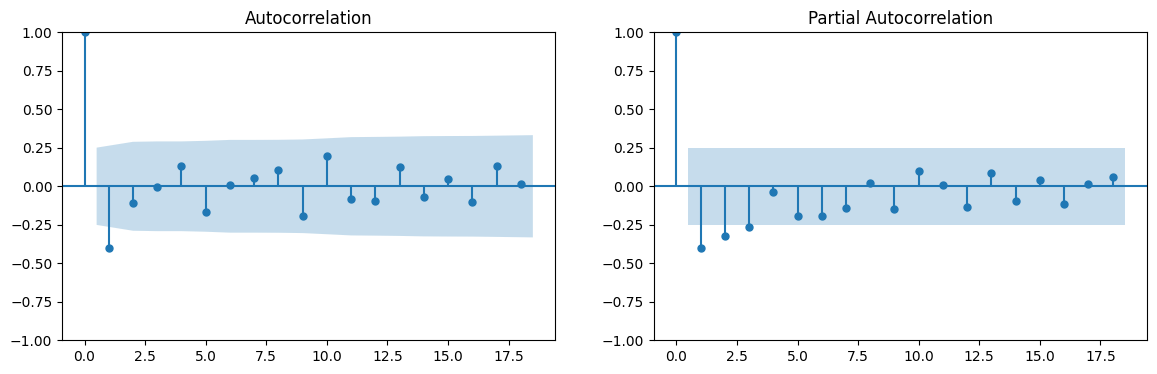

In [27]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
# Forecasting the demand using a SARIMA
df['Date'] = pd.to_datetime(df['Date']) # to change the date
time_series = df.set_index('Date')['Demand'] # to set the index
differenced_series = time_series.diff().dropna() # to bring the diff from one to another and drop the na values

# plot acf and pacf
fig, axes = plt.subplots(1,2,figsize=(14,4)) # making subplots and fig size
plot_acf(differenced_series, ax=axes[0]) # plotting acf
plot_pacf(differenced_series, ax=axes[1]) # plotting pacf
plt.show()

In [35]:
# P , D , Q values will be (1,1,1)
# Lets train the model and forecast demand for 10 days

order = (1,1,1)
seasonal_order =(1,1,1,2) # 2 because of 2 months data
model = SARIMAX(time_series, order=order, seasonal_order=seasonal_order)
model_fit = model.fit(disp=False)

future_steps = 10
predictions = model_fit.predict(start=len(time_series), end=len(time_series)+ future_steps -1)
predictions = predictions.astype(int)
print(predictions)


2023-08-02    117
2023-08-03    116
2023-08-04    130
2023-08-05    114
2023-08-06    128
2023-08-07    115
2023-08-08    129
2023-08-09    115
2023-08-10    129
2023-08-11    115
Freq: D, Name: predicted_mean, dtype: int64


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency D will be used.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency D will be used.



In [ ]:
# Inventory optimization, optimize the inventory using 10 days of forecasted demand

